# T3.1 - Devanagari Digit Recognition

**Assignment:** SMAI Assignment 3 - Build a Real ML App  
**Topic:** T3 - Handwritten Indic Script Recognition  
**Variant:** T3.1 - Devanagari digits  
**Dataset:** UCI Devanagari Handwritten Character Dataset, id 389, digit subset

Outputs: CNN weights, metadata

## 1. Imports and Reproducibility

In [1]:
import json
import random
import time
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
WORK_DIR = Path('/kaggle/working') if Path('/kaggle').exists() else Path('.')
DATA_DIR = WORK_DIR / 'data'
MODEL_DIR = WORK_DIR / 'models'
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('PyTorch version:', torch.__version__)
print('Device:', device)
print('Working directory:', WORK_DIR)

PyTorch version: 2.10.0+cu128
Device: cuda
Working directory: /kaggle/working


## 2. Download and Extract Dataset

The full UCI dataset has 46 classes. T3.1 uses only the digit folders:

- `digit_0` to `digit_9`
- 17,000 train images
- 3,000 test images
- 20,000 total digit images

In [2]:
DATASET_URL = 'https://archive.ics.uci.edu/static/public/389/devanagari+handwritten+character+dataset.zip'
ZIP_PATH = DATA_DIR / 'devanagari_handwritten_character_dataset.zip'
EXTRACT_DIR = DATA_DIR / 'devanagari'

if not ZIP_PATH.exists():
    print('Downloading dataset from UCI...')
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
else:
    print('Dataset zip already exists.')

if not (EXTRACT_DIR / 'DevanagariHandwrittenCharacterDataset').exists():
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
else:
    print('Dataset already extracted.')

ROOT = EXTRACT_DIR / 'DevanagariHandwrittenCharacterDataset'
TRAIN_DIR = ROOT / 'Train'
TEST_DIR = ROOT / 'Test'

CLASS_NAMES = [f'digit_{i}' for i in range(10)]
DEVANAGARI_DIGITS = ['०', '१', '२', '३', '४', '५', '६', '७', '८', '९']
UNICODE_CODES = [f'U+{ord(ch):04X}' for ch in DEVANAGARI_DIGITS]

train_counts = {c: len(list((TRAIN_DIR / c).glob('*.png'))) for c in CLASS_NAMES}
test_counts = {c: len(list((TEST_DIR / c).glob('*.png'))) for c in CLASS_NAMES}

print('Training counts:', train_counts)
print('Test counts:', test_counts)
print('Total digit images:', sum(train_counts.values()) + sum(test_counts.values()))

Extracting dataset...
Training counts: {'digit_0': 1700, 'digit_1': 1700, 'digit_2': 1700, 'digit_3': 1700, 'digit_4': 1700, 'digit_5': 1700, 'digit_6': 1700, 'digit_7': 1700, 'digit_8': 1700, 'digit_9': 1700}
Test counts: {'digit_0': 300, 'digit_1': 300, 'digit_2': 300, 'digit_3': 300, 'digit_4': 300, 'digit_5': 300, 'digit_6': 300, 'digit_7': 300, 'digit_8': 300, 'digit_9': 300}
Total digit images: 20000


## 3. Visualize Samples

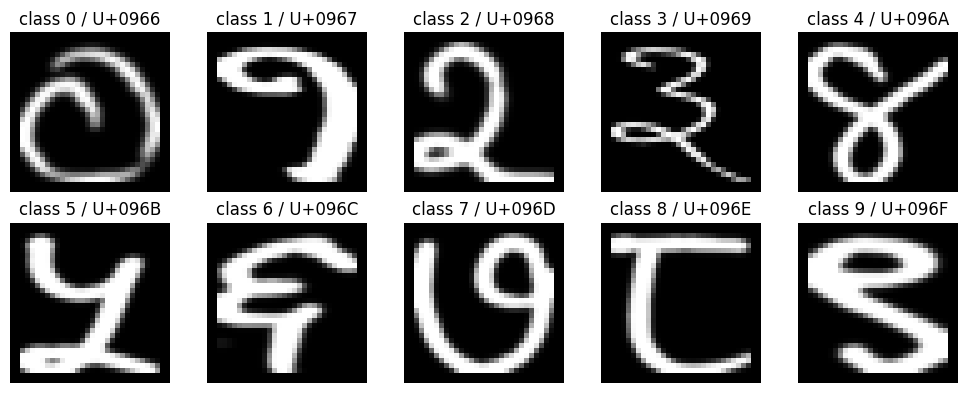

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    sample_path = sorted((TRAIN_DIR / f'digit_{i}').glob('*.png'))[0]
    img = Image.open(sample_path).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(f'class {i} / {UNICODE_CODES[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Create PyTorch Dataset and DataLoaders

Only basic preprocessing is used:

- grayscale image loading,
- conversion to a tensor shape of `(1, 32, 32)`,
- pixel normalization to `[0, 1]`.

A stratified 10% validation split is taken from the official training split. The official test split is untouched until final evaluation.

In [4]:
IMG_SIZE = (32, 32)
BATCH_SIZE = 128
NUM_WORKERS = 2

def collect_split_paths(split_dir):
    paths, labels = [], []
    for label, class_name in enumerate(CLASS_NAMES):
        class_paths = sorted((split_dir / class_name).glob('*.png'))
        paths.extend(class_paths)
        labels.extend([label] * len(class_paths))
    return np.array(paths, dtype=object), np.array(labels, dtype=np.int64)

def stratified_train_val_split(paths, labels, val_fraction=0.10):
    rng = np.random.default_rng(SEED)
    train_indices, val_indices = [], []
    for label in sorted(np.unique(labels)):
        label_indices = np.where(labels == label)[0]
        rng.shuffle(label_indices)
        val_count = int(len(label_indices) * val_fraction)
        val_indices.extend(label_indices[:val_count])
        train_indices.extend(label_indices[val_count:])
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    return paths[train_indices], labels[train_indices], paths[val_indices], labels[val_indices]

class DevanagariDigitDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = list(paths)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L').resize(IMG_SIZE)
        arr = np.array(img, dtype=np.float32) / 255.0
        tensor = torch.from_numpy(arr).unsqueeze(0)
        label = self.labels[idx]
        return tensor, label

all_train_paths, all_train_labels = collect_split_paths(TRAIN_DIR)
test_paths, test_labels = collect_split_paths(TEST_DIR)
train_paths, train_labels, val_paths, val_labels = stratified_train_val_split(all_train_paths, all_train_labels)

train_dataset = DevanagariDigitDataset(train_paths, train_labels)
val_dataset = DevanagariDigitDataset(val_paths, val_labels)
test_dataset = DevanagariDigitDataset(test_paths, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Train images:', len(train_dataset))
print('Validation images:', len(val_dataset))
print('Test images:', len(test_dataset))

Train images: 15300
Validation images: 1700
Test images: 3000


## 5. Define a Small 3-Layer CNN

This model has three convolutional layers and about 290k trainable parameters, matching the assignment's suggested small-CNN scale. It is trained from scratch.

In [5]:
class SmallDevanagariCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.20),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 24),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(24, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SmallDevanagariCNN(num_classes=10).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Trainable parameters: {num_params:,}')

SmallDevanagariCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout2d(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=24, bias=True)
    (2): ReLU(inplace=True)
  

## 6. Training and Evaluation Helpers

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

def run_epoch(model, loader, train=False):
    model.train() if train else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

def predict_loader(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            y_prob.append(probs)
            y_pred.extend(probs.argmax(axis=1).tolist())
            y_true.extend(labels.numpy().tolist())
    return np.array(y_true), np.array(y_pred), np.vstack(y_prob)

## 7. Train the Model

In [7]:
EPOCHS = 12
PATIENCE = 3
BEST_MODEL_PATH = MODEL_DIR / 'devanagari_digit_cnn.pt'

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
}

best_val_acc = 0.0
epochs_without_improvement = 0
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, train=False)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    lr = optimizer.param_groups[0]['lr']
    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | lr={lr:.6f}'
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': CLASS_NAMES,
            'devanagari_digits': DEVANAGARI_DIGITS,
            'unicode_codes': UNICODE_CODES,
            'image_size': IMG_SIZE,
            'num_params': num_params,
            'best_val_acc': best_val_acc,
        }, BEST_MODEL_PATH)
        print('  saved new best model')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print('Early stopping triggered.')
        break

elapsed = time.time() - start_time
print(f'Training time: {elapsed:.1f} seconds')
print(f'Best validation accuracy: {best_val_acc:.4%}')

Epoch 01/12 | train_loss=0.4894 train_acc=0.8431 | val_loss=0.0472 val_acc=0.9906 | lr=0.001000
  saved new best model
Epoch 02/12 | train_loss=0.1617 train_acc=0.9466 | val_loss=0.0526 val_acc=0.9853 | lr=0.001000
Epoch 03/12 | train_loss=0.1130 train_acc=0.9616 | val_loss=0.0260 val_acc=0.9918 | lr=0.001000
  saved new best model
Epoch 04/12 | train_loss=0.0869 train_acc=0.9710 | val_loss=0.0204 val_acc=0.9959 | lr=0.001000
  saved new best model
Epoch 05/12 | train_loss=0.0806 train_acc=0.9728 | val_loss=0.0342 val_acc=0.9924 | lr=0.001000
Epoch 06/12 | train_loss=0.0734 train_acc=0.9745 | val_loss=0.0155 val_acc=0.9959 | lr=0.001000
Epoch 07/12 | train_loss=0.0736 train_acc=0.9759 | val_loss=0.0180 val_acc=0.9965 | lr=0.001000
  saved new best model
Epoch 08/12 | train_loss=0.0611 train_acc=0.9786 | val_loss=0.0157 val_acc=0.9953 | lr=0.000500
Epoch 09/12 | train_loss=0.0499 train_acc=0.9843 | val_loss=0.0151 val_acc=0.9959 | lr=0.000500
Epoch 10/12 | train_loss=0.0451 train_acc=0.

## 8. Plot Training Curves

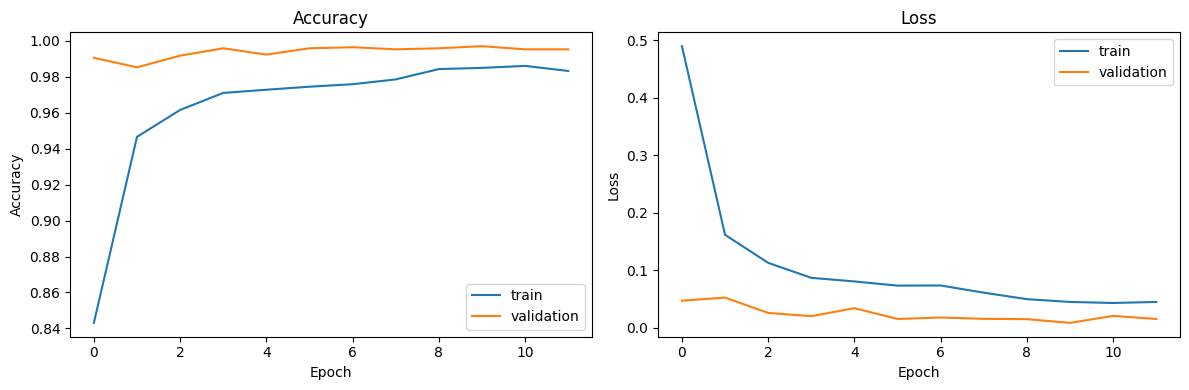

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_acc'], label='train')
axes[0].plot(history['val_acc'], label='validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history['train_loss'], label='train')
axes[1].plot(history['val_loss'], label='validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Final Test Evaluation

The official UCI test split is used only here. The assignment target is 97%+ accuracy; this model should typically exceed that on Kaggle GPU.

In [9]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc = run_epoch(model, test_loader, train=False)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4%}')

Test loss: 0.0136
Test accuracy: 99.6000%


              precision    recall  f1-score   support

  0 (U+0966)     1.0000    1.0000    1.0000       300
  1 (U+0967)     1.0000    0.9967    0.9983       300
  2 (U+0968)     0.9867    0.9867    0.9867       300
  3 (U+0969)     0.9868    0.9933    0.9900       300
  4 (U+096A)     1.0000    0.9933    0.9967       300
  5 (U+096B)     0.9933    0.9933    0.9933       300
  6 (U+096C)     0.9967    1.0000    0.9983       300
  7 (U+096D)     1.0000    1.0000    1.0000       300
  8 (U+096E)     0.9967    1.0000    0.9983       300
  9 (U+096F)     1.0000    0.9967    0.9983       300

    accuracy                         0.9960      3000
   macro avg     0.9960    0.9960    0.9960      3000
weighted avg     0.9960    0.9960    0.9960      3000



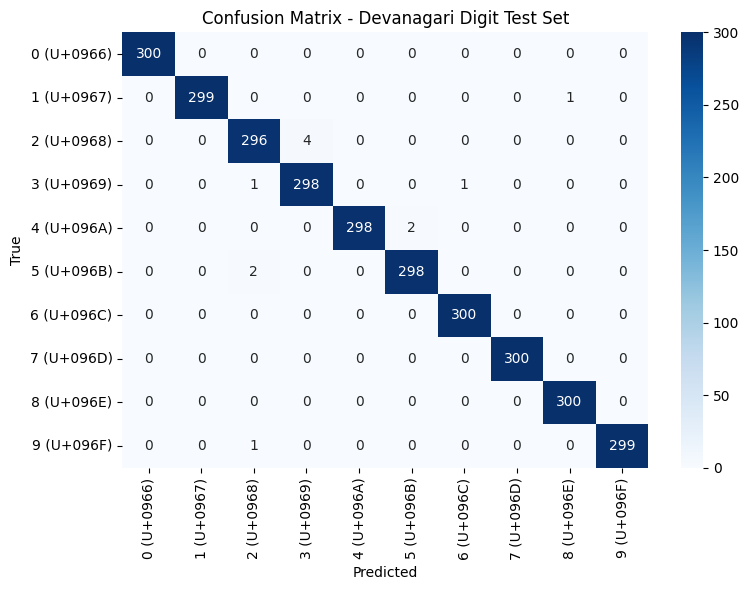

In [10]:
y_true, y_pred, y_prob = predict_loader(model, test_loader)

target_names = [f'{i} ({UNICODE_CODES[i]})' for i in range(10)]
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Devanagari Digit Test Set')
plt.tight_layout()
plt.show()

## 10. Inspect Misclassified Samples

Incorrect predictions: 12 out of 3000


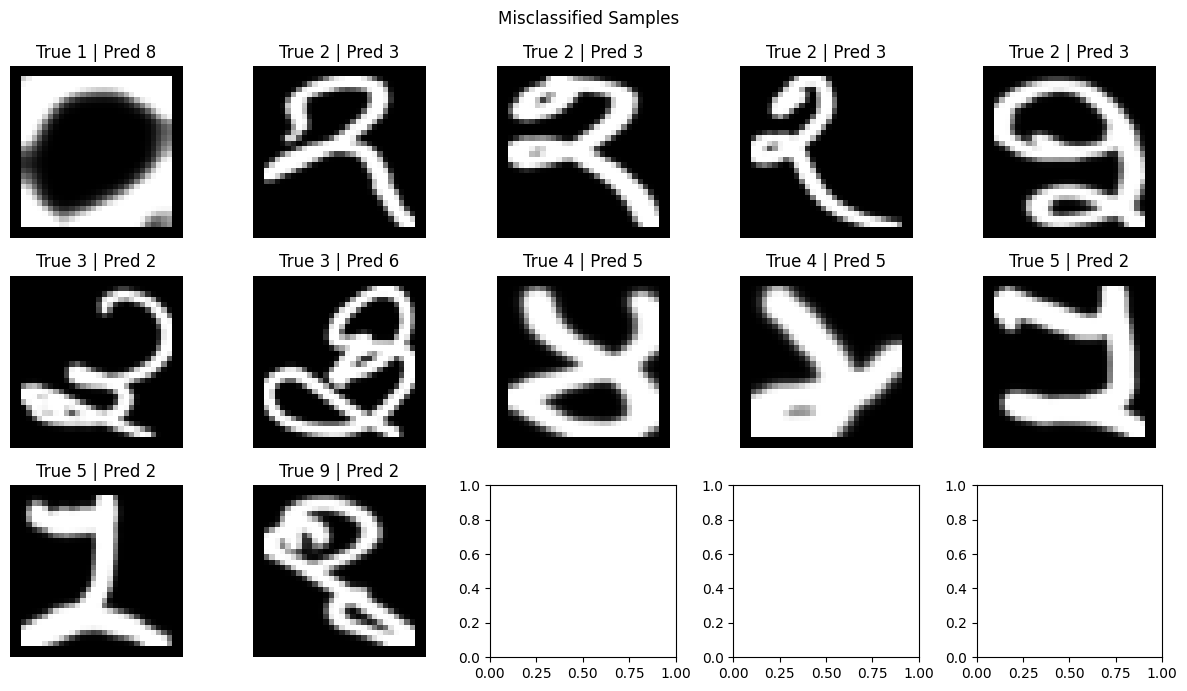

In [11]:
wrong_idx = np.where(y_true != y_pred)[0]
print('Incorrect predictions:', len(wrong_idx), 'out of', len(y_true))

show_idx = wrong_idx[:15] if len(wrong_idx) else np.arange(min(15, len(y_true)))
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for ax, idx in zip(axes.ravel(), show_idx):
    img = Image.open(test_paths[idx]).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True {y_true[idx]} | Pred {y_pred[idx]}')
    ax.axis('off')
plt.suptitle('Misclassified Samples' if len(wrong_idx) else 'Sample Predictions')
plt.tight_layout()
plt.show()

## 11. Save Metadata and Bundle Outputs

The separate Streamlit app will need both files:

- `devanagari_digit_cnn.pt`: model weights and class mapping
- `class_metadata.json`: class-to-Unicode mapping and model details

In [ ]:
metadata = {
    'class_names': CLASS_NAMES,
    'devanagari_digits': DEVANAGARI_DIGITS,
    'unicode_codes': UNICODE_CODES,
    'image_size': list(IMG_SIZE),
    'model_type': 'SmallDevanagariCNN',
    'framework': 'PyTorch',
    'num_params': int(num_params),
    'best_val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
}

META_PATH = MODEL_DIR / 'class_metadata.json'
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

HISTORY_PATH = MODEL_DIR / 'training_history.json'
with open(HISTORY_PATH, 'w', encoding='utf-8') as f:
    json.dump(history, f, indent=2)

ZIP_OUT = WORK_DIR / 'model_outputs.zip'
with zipfile.ZipFile(ZIP_OUT, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(BEST_MODEL_PATH, arcname='models/devanagari_digit_cnn.pt')
    zf.write(META_PATH, arcname='models/class_metadata.json')
    zf.write(HISTORY_PATH, arcname='models/training_history.json')

print('Saved model:', BEST_MODEL_PATH)
print('Saved metadata:', META_PATH)
print('Saved training history:', HISTORY_PATH)
print('Created output bundle:', ZIP_OUT)

Saved model: /kaggle/working/models/devanagari_digit_cnn.pt
Saved metadata: /kaggle/working/models/class_metadata.json
Saved training history: /kaggle/working/models/training_history.json
Created output bundle: /kaggle/working/t3_1_pytorch_training_outputs.zip
